In [1]:
import geopandas as gpd
import pandas as pd
from app import *
import matplotlib

In [2]:
ano = 2024

In [3]:
agg_atributos = {
        'Quantidade de Unidades':'sum',
        'Quantidade de Unidades Condominiais':'sum',
        'Tamanho Médio da Unidade Condominial':'mean',
        'Tamanho médio dos Terrenos':'mean',
        'Área Total dos lotes':'sum',
        'Área Total Ocupada':'sum',
        'Área Total Construída':'sum',
        'Valor Total dos Terrenos':'sum',
        'Valor Total das Construções':'sum',
        'CA médio':'mean',
        'TO médio':'mean',
        'CA médio em lotes condominiais':'mean',
        'TO médio em lotes condominiais':'mean',
        'CA médio em lotes não condominiais':'mean',
        'TO médio em lotes não condominiais':'mean',
        'Comprimento Médio da Testada':'mean',
        'Número médio de Pavimentos':'mean',
        'Fator de obsolecência médio':'mean',
        'Residencial vertical Baixo (m2)':'sum',
        'Residencial vertical Médio (m2)':'sum',
        'Residencial vertical Alto (m2)':'sum',
        'Residencial horizontal Baixo (m2)':'sum',
        'Residencial horizontal Médio (m2)':'sum',
        'Residencial horizontal Alto (m2)':'sum',
        'Comercial vertical Baixo (m2)':'sum',
        'Comercial vertical Médio (m2)':'sum',
        'Comercial vertical Alto (m2)':'sum',
        'Comercial horizontal Baixo (m2)':'sum',
        'Comercial horizontal Alto (m2)':'sum',
        'Comercial horizontal Médio (m2)':'sum',
        'Terreno (m2)':'sum',
        'Outros Usos (m2)':'sum',
        'Residencial vertical Baixo (qt)':'sum',
        'Residencial vertical Médio (qt)':'sum',
        'Residencial vertical Alto (qt)':'sum',
        'Residencial horizontal Baixo (qt)':'sum',
        'Residencial horizontal Médio (qt)':'sum',
        'Residencial horizontal Alto (qt)':'sum',
        'Comercial vertical Baixo (qt)':'sum',
        'Comercial vertical Médio (qt)':'sum',
        'Comercial vertical Alto (qt)':'sum',
        'Comercial horizontal Baixo (qt)':'sum',
        'Comercial horizontal Alto (qt)':'sum',
        'Comercial horizontal Médio (qt)':'sum',
        'Terreno (qt)':'sum',
        'Outros Usos (qt)':'sum'
}

In [4]:
gdf_distritos = gpd.read_file('data/SIRGAS_GPKG_distrito.gpkg')

In [7]:
distrito = gdf_distritos.loc[52]
print(distrito.ds_nome)
distrito = gdf_distritos[gdf_distritos.ds_codigo == distrito.ds_codigo].iloc[0]
path = f'lotes_agregados_por_ano/{ano}/SIRGAS_SHP_LOTES_{distrito.ds_codigo.rjust(2, "0")}_{distrito.ds_nome.replace(" ", "_")}_IPTU_{ano}.gpkg'
gdf_lote = gpd.read_file(path).drop_duplicates(subset=['sqlc']).set_index('sqlc')
gdf_lote

BUTANTA


,sq,agregado,geometry
sqlc,,,
101583021300,101583,False,"POLYGON ((322234.801 7391562.481, 322245.389 7..."
101190004200,101190,False,"POLYGON ((323048.751 7390338.78, 323050.911 73..."
101215004600,101215,False,"POLYGON ((324078.99 7391123.767, 324086.931 73..."
101201003700,101201,False,"POLYGON ((323280.158 7390718.299, 323279.429 7..."
101238001900,101238,False,"POLYGON ((324827.02 7391558.02, 324812.59 7391..."
...,...,...,...
200049000000,200049,True,None
200050000000,200050,True,None
200051000000,200051,True,"POLYGON ((326074.691 7392108.175, 326076.67 73..."


<Axes: >

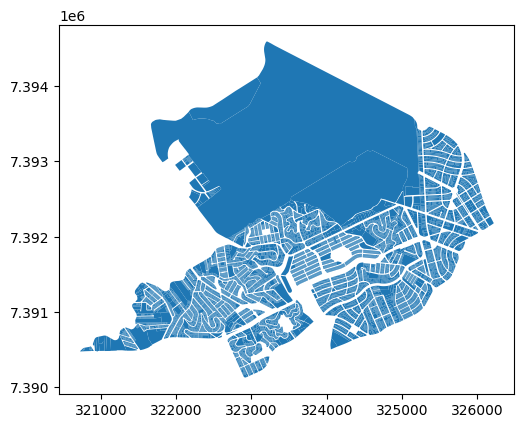

In [8]:
gdf_lote.plot()

In [37]:
path = f'data/por_distritos/IPTU-1995-{ano}-agrupados-por-sqlc-{distrito.ds_codigo}-{distrito.ds_nome.replace(" ", "-").lower()}.hdf5'

In [48]:
import pandas as pd
# Reads a DataFrame from Vaex HDF5 format
df = read_vaex_hdf5(path)
df

,sqlc,ano,Quantidade de Unidades,Quantidade de Unidades Condominiais,Tamanho Médio da Unidade Condominial,Tamanho médio dos Terrenos,Área Total dos lotes,Área Total Ocupada,Área Total Construída,Valor Total dos Terrenos,...,Residencial horizontal Médio (qt),Residencial horizontal Alto (qt),Comercial vertical Baixo (qt),Comercial vertical Médio (qt),Comercial vertical Alto (qt),Comercial horizontal Baixo (qt),Comercial horizontal Alto (qt),Comercial horizontal Médio (qt),Terreno (qt),Outros Usos (qt)
0,b'0',1995,1,0,NaN,392.0,392.0,50.0,50,19600.0,...,0,0,0,0,0,0,0,0,0,0
1,b'8',1996,1,0,NaN,392.0,392.0,50.0,50,30576.0,...,0,0,0,0,0,0,0,0,0,0
2,b'2',1997,1,0,NaN,392.0,392.0,50.0,50,33712.0,...,0,0,0,0,0,0,0,0,0,0
3,b'3',1998,1,0,NaN,392.0,392.0,50.0,50,35672.0,...,0,0,0,0,0,0,0,0,0,0
4,b'5',1999,1,0,NaN,392.0,392.0,50.0,50,36064.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390301,b'8',2020,1,0,NaN,635.0,635.0,236.0,609,603885.0,...,0,1,0,0,0,0,0,0,0,0
390302,b'2',2021,1,0,NaN,635.0,635.0,236.0,609,603885.0,...,0,1,0,0,0,0,0,0,0,0
390303,b'3',2022,1,0,NaN,635.0,635.0,236.0,609,1000125.0,...,0,1,0,0,0,0,0,0,0,0
390304,b'6',2023,1,0,NaN,635.0,635.0,227.0,625,1054735.0,...,0,1,0,0,0,0,0,0,0,0


In [44]:
import h5py
with h5py.File(path, "r") as f:
    # Print all root level object names (aka keys) 
    print("Keys: %s" % list(f.keys()))
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]
    print(f"First key: {a_group_key}")

    # get the object type for a_group_key: usually group or dataset
    obj = f[a_group_key]
    print(f"Type: {type(obj)}")
    
    # If it's a group, see what's inside
    if isinstance(obj, h5py.Group):
        print(f"Contents of '{a_group_key}': {list(obj.keys())}")

Keys: ['table']
First key: table
Type: <class 'h5py._hl.group.Group'>
Contents of 'table': ['columns']


In [51]:
df_iptu = read_vaex_hdf5(f'data/por_distritos/IPTU-1995-{ano}-agrupados-por-sqlc-{distrito.ds_codigo}-{distrito.ds_nome.replace(" ", "-").lower()}.hdf5')#.set_index('sqlc')
df_iptu

,sqlc,ano,Quantidade de Unidades,Quantidade de Unidades Condominiais,Tamanho Médio da Unidade Condominial,Tamanho médio dos Terrenos,Área Total dos lotes,Área Total Ocupada,Área Total Construída,Valor Total dos Terrenos,...,Residencial horizontal Médio (qt),Residencial horizontal Alto (qt),Comercial vertical Baixo (qt),Comercial vertical Médio (qt),Comercial vertical Alto (qt),Comercial horizontal Baixo (qt),Comercial horizontal Alto (qt),Comercial horizontal Médio (qt),Terreno (qt),Outros Usos (qt)
0,b'0',1995,1,0,NaN,392.0,392.0,50.0,50,19600.0,...,0,0,0,0,0,0,0,0,0,0
1,b'8',1996,1,0,NaN,392.0,392.0,50.0,50,30576.0,...,0,0,0,0,0,0,0,0,0,0
2,b'2',1997,1,0,NaN,392.0,392.0,50.0,50,33712.0,...,0,0,0,0,0,0,0,0,0,0
3,b'3',1998,1,0,NaN,392.0,392.0,50.0,50,35672.0,...,0,0,0,0,0,0,0,0,0,0
4,b'5',1999,1,0,NaN,392.0,392.0,50.0,50,36064.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390301,b'8',2020,1,0,NaN,635.0,635.0,236.0,609,603885.0,...,0,1,0,0,0,0,0,0,0,0
390302,b'2',2021,1,0,NaN,635.0,635.0,236.0,609,603885.0,...,0,1,0,0,0,0,0,0,0,0
390303,b'3',2022,1,0,NaN,635.0,635.0,236.0,609,1000125.0,...,0,1,0,0,0,0,0,0,0,0
390304,b'6',2023,1,0,NaN,635.0,635.0,227.0,625,1054735.0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
lotes_existentes = gdf_lote.join(df_iptu, how='inner')
lotes_sg = df_iptu.join(gdf_lote, how='left').sq.isna()
df_lotes_sg = df_iptu[lotes_sg].reset_index()
df_lotes_sg.sqlc = df_lotes_sg.sqlc.str[:6] + '000000'
df_lotes_sg_group = df_lotes_sg.groupby('sqlc').agg(agg_atributos)
lotes_agregados = gdf_lote.join(df_lotes_sg_group, how='inner')
lotes = pd.concat([lotes_existentes, lotes_agregados])
lotes

In [5]:
for distrito in gdf_distritos.iterrows():
    print(distrito[1].ds_nome)
    distrito = gdf_distritos[gdf_distritos.ds_codigo == distrito[1].ds_codigo].iloc[0]
    path = f'lotes_agregados_por_ano/{ano}/SIRGAS_SHP_LOTES_{distrito.ds_codigo.rjust(2, "0")}_{distrito.ds_nome.replace(" ", "_")}_IPTU_{ano}.gpkg'
    gdf_lote = gpd.read_file(path).drop_duplicates(subset=['sqlc']).set_index('sqlc')
    df_iptu = read_vaex_hdf5(f'data/por_distritos/IPTU-1995-{EXERCICIO}-agrupados-por-sqlc-{distrito.ds_codigo}-{distrito.ds_nome.replace(" ", "-").lower()}.hdf5').set_index('sqlc')
    df_iptu = df_iptu[df_iptu.ano == ano]
    lotes_existentes = gdf_lote.join(df_iptu, how='inner')
    lotes_sg = df_iptu.join(gdf_lote, how='left').sq.isna()
    df_lotes_sg = df_iptu[lotes_sg].reset_index()
    df_lotes_sg.sqlc = df_lotes_sg.sqlc.str[:6] + '000000'
    df_lotes_sg_group = df_lotes_sg.groupby('sqlc').agg(agg_atributos)
    lotes_agregados = gdf_lote.join(df_lotes_sg_group, how='inner')
    lotes = pd.concat([lotes_existentes, lotes_agregados])
    lotes.to_file(f"iptu_por_lotes/{ano}/IPTU-SP-todos-atributos-por-lotes-{distrito.ds_codigo}-{distrito.ds_nome.lower().replace(' ', '-')}.gpkg", driver='GPKG')
    # break

PIRITUBA
SAO DOMINGOS
JARAGUA
BRASILANDIA
FREGUESIA DO O
CASA VERDE
CACHOEIRINHA
LIMAO
VILA GUILHERME
VILA MARIA
VILA MEDEIROS
ARTUR ALVIM
PENHA
CANGAIBA
VILA MATILDE
PONTE RASA
ERMELINO MATARAZZO
VILA CURUCA
ITAIM PAULISTA
GUAIANASES
LAJEADO
BARRA FUNDA
PERDIZES
VILA LEOPOLDINA
JAGUARA
LAPA
JAGUARE
REPUBLICA
SANTA CECILIA
SE
BELA VISTA
BOM RETIRO
CAMBUCI
CONSOLACAO
LIBERDADE
MOOCA
PARI
TATUAPE
AGUA RASA
BELEM
BRAS
CARRAO
VILA FORMOSA
ARICANDUVA
SAO MATEUS
SAO RAFAEL
IGUATEMI
VILA PRUDENTE
SAO LUCAS
MORUMBI
RIO PEQUENO
VILA SONIA
BUTANTA
RAPOSO TAVARES
PINHEIROS
ALTO DE PINHEIROS
ITAIM BIBI
JARDIM PAULISTA
CAMPO LIMPO
CAPAO REDONDO
VILA ANDRADE
JARDIM ANGELA
JARDIM SAO LUIS
SOCORRO
CIDADE DUTRA
GRAJAU
MARSILAC
PARELHEIROS
CIDADE TIRADENTES
PERUS
ANHANGUERA
SAPOPEMBA
SACOMA
CURSINO
IPIRANGA
MOEMA
SAUDE
VILA MARIANA
PEDREIRA
CIDADE ADEMAR
JACANA
TREMEMBE
MANDAQUI
SANTANA
TUCURUVI
SANTO AMARO
CAMPO GRANDE
CAMPO BELO
JABAQUARA
VILA JACUI
SAO MIGUEL
JARDIM HELENA
CIDADE LIDER
PARQUE DO CARM

In [6]:
df_iptu = df_iptu[df_iptu.ano == ano]
lotes_existentes = gdf_lote.join(df_iptu, how='inner')
lotes_sg = df_iptu.join(gdf_lote, how='left').sq.isna()
df_lotes_sg = df_iptu[lotes_sg].reset_index()
df_lotes_sg.sqlc = df_lotes_sg.sqlc.str[:6] + '000000'
df_lotes_sg_group = df_lotes_sg.groupby('sqlc').agg(agg_atributos)
lotes_agregados = gdf_lote.join(df_lotes_sg_group, how='inner')
lotes = pd.concat([lotes_existentes, lotes_agregados])

In [7]:
lotes

,sq,agregado,geometry,ano,Quantidade de Unidades,Quantidade de Unidades Condominiais,Tamanho Médio da Unidade Condominial,Tamanho médio dos Terrenos,Área Total dos lotes,Área Total Ocupada,...,Residencial horizontal Médio (qt),Residencial horizontal Alto (qt),Comercial vertical Baixo (qt),Comercial vertical Médio (qt),Comercial vertical Alto (qt),Comercial horizontal Baixo (qt),Comercial horizontal Alto (qt),Comercial horizontal Médio (qt),Terreno (qt),Outros Usos (qt)
sqlc,,,,,,,,,,,,,,,,,,,,,
114121016900,114121,False,"POLYGON ((351097.89 7395426.203, 351099.341 73...",2024.0,1,0,NaN,80.0,80.000000,80.000000,...,0,0,0,0,0,0,0,0,0,0
114108001300,114108,False,"POLYGON ((351746.508 7395459.504, 351750.912 7...",2024.0,1,0,NaN,120.0,120.000000,80.000000,...,0,0,0,0,0,0,0,0,0,0
142137004000,142137,False,"POLYGON ((350139.321 7396509.945, 350137.08 73...",2024.0,1,0,NaN,195.0,195.000000,70.000000,...,0,0,0,0,0,0,0,0,0,0
142125000800,142125,False,"POLYGON ((349909.394 7396651.58, 349909.401 73...",2024.0,1,0,NaN,300.0,300.000000,60.000000,...,0,0,0,0,0,0,0,0,0,0
114188007100,114188,False,"POLYGON ((350696.11 7395823.335, 350688.208 73...",2024.0,1,0,NaN,295.0,295.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142148000000,142148,True,"POLYGON ((350193.644 7396202.705, 350223.748 7...",NaN,1,0,NaN,215.0,215.000000,65.000000,...,0,0,0,0,0,0,0,0,0,0
143072000000,143072,True,"MULTIPOLYGON (((350776.714 7395236.292, 350757...",NaN,71,70,52.641667,1532.0,4594.725079,753.676018,...,0,0,0,0,0,0,0,0,1,0
144008000000,144008,True,"POLYGON ((352373.885 7395967.315, 352376.54 73...",NaN,1,0,NaN,70.0,70.000000,33.000000,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df_iptu

,ano,Quantidade de Unidades,Quantidade de Unidades Condominiais,Tamanho Médio da Unidade Condominial,Tamanho médio dos Terrenos,Área Total dos lotes,Área Total Ocupada,Área Total Construída,Valor Total dos Terrenos,Valor Total das Construções,...,Residencial horizontal Médio (qt),Residencial horizontal Alto (qt),Comercial vertical Baixo (qt),Comercial vertical Médio (qt),Comercial vertical Alto (qt),Comercial horizontal Baixo (qt),Comercial horizontal Alto (qt),Comercial horizontal Médio (qt),Terreno (qt),Outros Usos (qt)
sqlc,,,,,,,,,,,,,,,,,,,,,
114022002900,2024,1,0,NaN,240.0,240.0,50.0,50,288000.0,63700.0,...,0,0,0,0,0,0,0,0,0,0
114029002900,2024,1,0,NaN,180.0,180.0,50.0,50,225900.0,63700.0,...,0,0,0,0,0,0,0,0,0,0
114033000400,2024,1,0,NaN,500.0,500.0,361.0,362,523500.0,532140.0,...,0,0,0,0,0,1,0,0,0,0
114039000800,2024,1,0,NaN,137.0,137.0,60.0,60,118916.0,76440.0,...,0,0,0,0,0,0,0,0,0,0
114052002300,2024,1,0,NaN,125.0,125.0,49.0,49,117250.0,74529.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114298013900,2024,1,0,NaN,68.0,68.0,34.0,68,83028.0,96560.0,...,0,0,0,0,0,0,0,0,0,0
114301000600,2024,1,0,NaN,308.0,308.0,0.0,0,409640.0,0.0,...,0,0,0,0,0,0,0,0,1,0
114301002900,2024,1,0,NaN,290.0,290.0,272.0,272,372360.0,419152.0,...,0,1,0,0,0,0,0,0,0,0
